#REGRESIÓN SIMBÓLICA

1. ¿Que es la regresión cimbolica?
* Técnica de Machine Learning que busca descubrir la ecuación matemática que mejor explica la relación entre las variables de un conjunto de datos.
* El algoritmo la explora y la construye automáticamentela forma de la ecuación.
* Resultado: una fórmula legible por humanos → se puede interpretar, analizar y usar para entender fenómenos, no solo para predecir.

2. La base: Programación Genética (PG)
* La PG es el motor que hace posible la regresión simbólica.
* Se inspira en la evolución biológica para ir “criando” ecuaciones cada vez mejores.

* Población inicial: se generan muchas ecuaciones aleatorias (fórmulas con sumas, restas, multiplicaciones, funciones trigonométricas, etc.).

* Evaluación: se mide qué tan buena es cada ecuación usando una función de aptitud (fitness), por ejemplo, el Error Cuadrático Medio (MSE).

* Selección: se eligen las mejores (o las menos malas) para ser “padres”.

* Reproducción:

-- Cruce: combinar partes de dos ecuaciones para crear una nueva.

-- Mutación: cambiar aleatoriamente un operador o número.

* Reemplazo: las nuevas fórmulas sustituyen a las peores de la generación anterior.

* Repetir: se itera por muchas generaciones hasta encontrar una buena ecuación.


3. Representación de las ecuaciones
* Se representan como árboles de expresión:
-- Nodos internos → Operadores (+, -, *, /, sin, log, …)
-- Hojas → Variables (X1, X2, …) o constantes (2.5, -0.8, …)

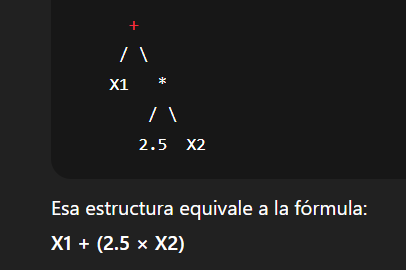

4. **Ventajas de usar árboles**
* Flexibilidad: se pueden representar fórmulas simples y muy complejas.
* Modularidad: se pueden intercambiar partes del árbol (subárboles) en el cruce.
* Facilita mutaciones localizadas (cambiar solo un nodo u operador).

5. **Control de complejidad**
* Un problema común en PG es el bloat (hinchazón): las fórmulas se vuelven muy largas y poco interpretables.

Se controla con:
 * Coeficiente de parsimonia: penaliza fórmulas largas.

 * Mutación de elevación: elimina partes innecesarias del árbol.

1

##Algoritmo paso paso aplicado a un caso (Yape)

Imagina que en Yape queremos descubrir la ecuación que predice el flujo de dinero promedio del cliente(que nos gustaría que aumentara):

* X1 = número de transacciones que hizo durante el año.
* X2 = monto promedio gastado por transacción.
* X3 = promedio de días entre recargas de saldo.
* X4 = número de promociones que recibió en el mes.

In [ ]:
!pip install gplearn

2

In [ ]:
#Ejemplo:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gplearn.genetic import SymbolicRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error
import graphviz

In [ ]:
#reproductibilidad
np.random.seed(42)
n = 850

3

In [ ]:
#variables simuladas
x1 = np.random.normal(100, 10, n)  #número de transacciones que hizo durante el año
x2 = np.random.normal(250, 8, n) #promedio de gasto por transacción
x3 = np.random.normal(8, 3, n)  #promedio de días entre recargas de saldo
x4 = np.random.normal(0, 6, n)   #número de promociones/notificaciones que recibió

In [ ]:
# simulación de la fórmula real para generar caracteristica de salida "y"
y_real = (x1 + (0.35*x4) - (x3/(x2+1))) + np.random.normal(0, 1, n)  #Flujo de dinero promedio del usuario



4

In [ ]:
df = pd.DataFrame({'intercept':1 ,'x1': x1, 'x2': x2, 'x3': x3, 'x4': x4, 'y': y_real})
df

,intercept,x1,x2,x3,x4,y
0,1,104.967142,245.014876,9.051890,-9.515900,102.091212
1,1,98.617357,245.556183,9.467561,-11.279546,95.200877
2,1,106.476885,244.900903,9.904164,11.225791,110.561117
3,1,115.230299,259.512132,11.329100,2.337685,115.906155
4,1,97.658466,261.364034,9.229456,-5.209756,96.235849
...,...,...,...,...,...,...
845,1,104.924513,265.511432,9.298879,-8.315928,100.435929
846,1,102.891686,241.997349,3.867147,3.033535,104.101804
847,1,124.553001,244.578040,6.305678,8.934679,129.850685
848,1,93.622600,254.111263,11.064150,13.628698,98.842261


5

In [ ]:
# Separar datos
X = df[['x1', 'x2', 'x3', 'x4']]
y = df['y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=True, random_state=42) #Particion de 25% para testeo y un 75% para entrenamiento

# Definir el modelo
est_gp = SymbolicRegressor(
    population_size=800,
    const_range=(-300, 300),
    tournament_size=15,
    metric= 'mean absolute error',
    generations=300,
    init_depth =(2 , 6),
    p_crossover=0.95,
    p_subtree_mutation=0.01,
    p_hoist_mutation=0.01,
    p_point_mutation=0.03,
    parsimony_coefficient=0.001,
    function_set=['add', 'sub', 'mul', 'div','sqrt', 'log', 'abs', 'neg', 'inv'],
    random_state=42,
    verbose=1
)

# Entrenamiento del modelo
est_gp.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    10.15      4.29873e+06        7          1.88861              N/A      5.01m
   1     9.16          1176.54       14          1.62315              N/A      5.75m
   2     6.34           439.82       14          1.28139              N/A      6.77m
   3     4.06          47.2188       13         0.872348              N/A      6.21m
   4     7.97          65.7199       13         0.872348              N/A     10.16m
   5    13.15          104.073       10         0.872357              N/A     11.14m
   6    16.12          124.138       13         0.872348              N/A      7.19m
   7    19.05          146.182       29         0.827591              N/A      8.45m
   8    20.74          157.069       29         0.825277              N/A  

SymbolicRegressor(const_range=(-300, 300),
                  function_set=['add', 'sub', 'mul', 'div', 'sqrt', 'log',
                                'abs', 'neg', 'inv'],
                  generations=300, p_crossover=0.95, p_point_mutation=0.03,
                  population_size=800, random_state=42, tournament_size=15,
                  verbose=1)

6

In [ ]:
# Predicciones y métricas
y_pred = est_gp.predict(X_test) #Flujo promedio de dinero encontrado por la formula de regresion simbolica
print("MAPE:", mean_absolute_percentage_error(y_test,y_pred))


MAPE: 0.008737558865815705


7

In [ ]:
#Ecuacion encontrada por el modelo
print(f'ecuación encontrada por el modelo: {est_gp._program}')

ecuación encontrada por el modelo: sub(X0, div(X3, div(X1, neg(88.340))))


* **Formula real = x1 + 0.35*x4 - (x3/(x2+1)) + np.random.normal(0, 0.3, n)**
* **Fórmula encontrada =  sub(X0, div(X3, div(X1, neg(88.340))))**

El modelo explica que el flujo de dinero promedio (Y) se incrementa principalmente por el número de transacciones. Sin embargo, los usuarios que reciben más promociones y que gastan poco en cada transacción, terminan aumentando un poco más el valor del flujo promedio, con un valor constante de 88.34 como divisor del gasto promedio por transacción.

In [ ]:
X0 = df.iloc[0]['x1'] #Transacciones por año
X1 = df.iloc[0]['x2'] #Gasto promedio por transacción
X2 = df.iloc[0]['x3'] #Promedio de días entre ingresos
X3 = df.iloc[0]['x4'] #Número de promociones recibidas

result = (X0-(X3/(X1/(-88.340))))
print(result)

101.53618823752979


In [ ]:
df

,intercept,x1,x2,x3,x4,y
0,1,104.967142,245.014876,9.051890,-9.515900,102.091212
1,1,98.617357,245.556183,9.467561,-11.279546,95.200877
2,1,106.476885,244.900903,9.904164,11.225791,110.561117
3,1,115.230299,259.512132,11.329100,2.337685,115.906155
4,1,97.658466,261.364034,9.229456,-5.209756,96.235849
...,...,...,...,...,...,...
845,1,104.924513,265.511432,9.298879,-8.315928,100.435929
846,1,102.891686,241.997349,3.867147,3.033535,104.101804
847,1,124.553001,244.578040,6.305678,8.934679,129.850685
848,1,93.622600,254.111263,11.064150,13.628698,98.842261


9

### VISUALIZACION DEL VOMPORTAMIENTO DEL MODELO COMO ÁRBOL DE EXPRESION

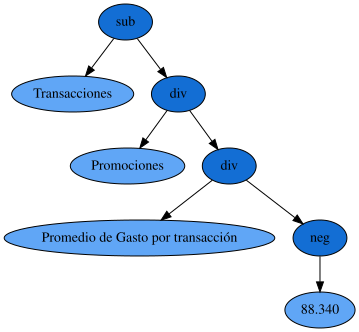

In [ ]:
# Exportar
dot_data = est_gp._program.export_graphviz()

# Reemplazar los nombres de variables
dot_data = dot_data.replace("X0", "Transacciones")
dot_data = dot_data.replace("X1", "Promedio de Gasto por transacción")
dot_data = dot_data.replace("X2", "Dias sin ingreso")
dot_data = dot_data.replace("X3", "Promociones")

#número de transacciones que hizo durante el año
#monto total gastado al año
#días desde su última recarga de saldo
#número de promociones/notificaciones que recibió en el mes el cliente

# Renderizar
graph = graphviz.Source(dot_data)
graph
